In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/semeval_eng_hin_crosslingual_results'
REPORT_DIR = os.path.join(OUTPUT_DIR, 'final_report_visuals')
os.makedirs(REPORT_DIR, exist_ok=True)

# --- All experiment results, manually recorded from prior runs ---
# Order reflects the chronological pipeline: baseline -> failed fine-tune ->
# recovery attempts -> best model (v4)
all_results = {
    'Frozen baseline':      {'success@1': 0.1812, 'success@5': 0.5125, 'success@10': 0.6375},
    'Original fine-tune':   {'success@1': 0.0375, 'success@5': 0.2000, 'success@10': 0.2812},
    'v1 (1ep, LR1e-5)':     {'success@1': 0.2062, 'success@5': 0.4875, 'success@10': 0.6188},
    'v1 + fusion':          {'success@1': 0.1938, 'success@5': 0.5000, 'success@10': 0.6375},
    'v2 (rank16, 2ep)':     {'success@1': 0.1500, 'success@5': 0.4250, 'success@10': 0.5437},
    'v3 (fixed dev)':       {'success@1': 0.1938, 'success@5': 0.5062, 'success@10': 0.6375},
    'v3 + rerank':          {'success@1': 0.1812, 'success@5': 0.5188, 'success@10': 0.6375},
    'v4 (diverse train)':   {'success@1': 0.2625, 'success@5': 0.5813, 'success@10': 0.6500},
}

df_results = pd.DataFrame(all_results).T
df_results.index.name = 'version'
print(df_results.to_string())

Mounted at /content/drive
                    success@1  success@5  success@10
version                                             
Frozen baseline        0.1812     0.5125      0.6375
Original fine-tune     0.0375     0.2000      0.2812
v1 (1ep, LR1e-5)       0.2062     0.4875      0.6188
v1 + fusion            0.1938     0.5000      0.6375
v2 (rank16, 2ep)       0.1500     0.4250      0.5437
v3 (fixed dev)         0.1938     0.5062      0.6375
v3 + rerank            0.1812     0.5188      0.6375
v4 (diverse train)     0.2625     0.5813      0.6500


✅ CSV saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_results.csv
✅ JSON saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_results.json


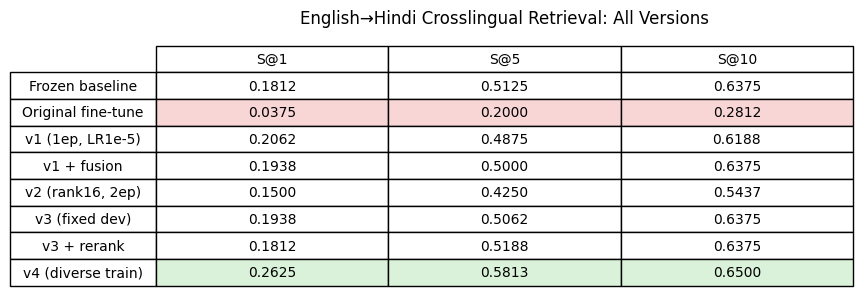

✅ Table image saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/results_table.png


In [2]:
# CSV + JSON
csv_path = os.path.join(REPORT_DIR, 'all_versions_results.csv')
json_path = os.path.join(REPORT_DIR, 'all_versions_results.json')
df_results.to_csv(csv_path)
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f'✅ CSV saved to: {csv_path}')
print(f'✅ JSON saved to: {json_path}')

# Styled table image (handy for slides/reports)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis('off')
tbl = ax.table(
    cellText=[[f'{v:.4f}' for v in row] for row in df_results.values],
    rowLabels=df_results.index,
    colLabels=[c.replace('success@', 'S@') for c in df_results.columns],
    cellLoc='center', rowLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Highlight the best row (v4) and the collapse row (Original fine-tune)
for j in range(len(df_results.columns)):
    tbl[(df_results.index.get_loc('v4 (diverse train)') + 1, j)].set_facecolor('#d9f2d9')
    tbl[(df_results.index.get_loc('Original fine-tune') + 1, j)].set_facecolor('#f9d6d6')

plt.title('English→Hindi Crosslingual Retrieval: All Versions', fontsize=12, pad=14)
table_img_path = os.path.join(REPORT_DIR, 'results_table.png')
plt.savefig(table_img_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Table image saved to: {table_img_path}')

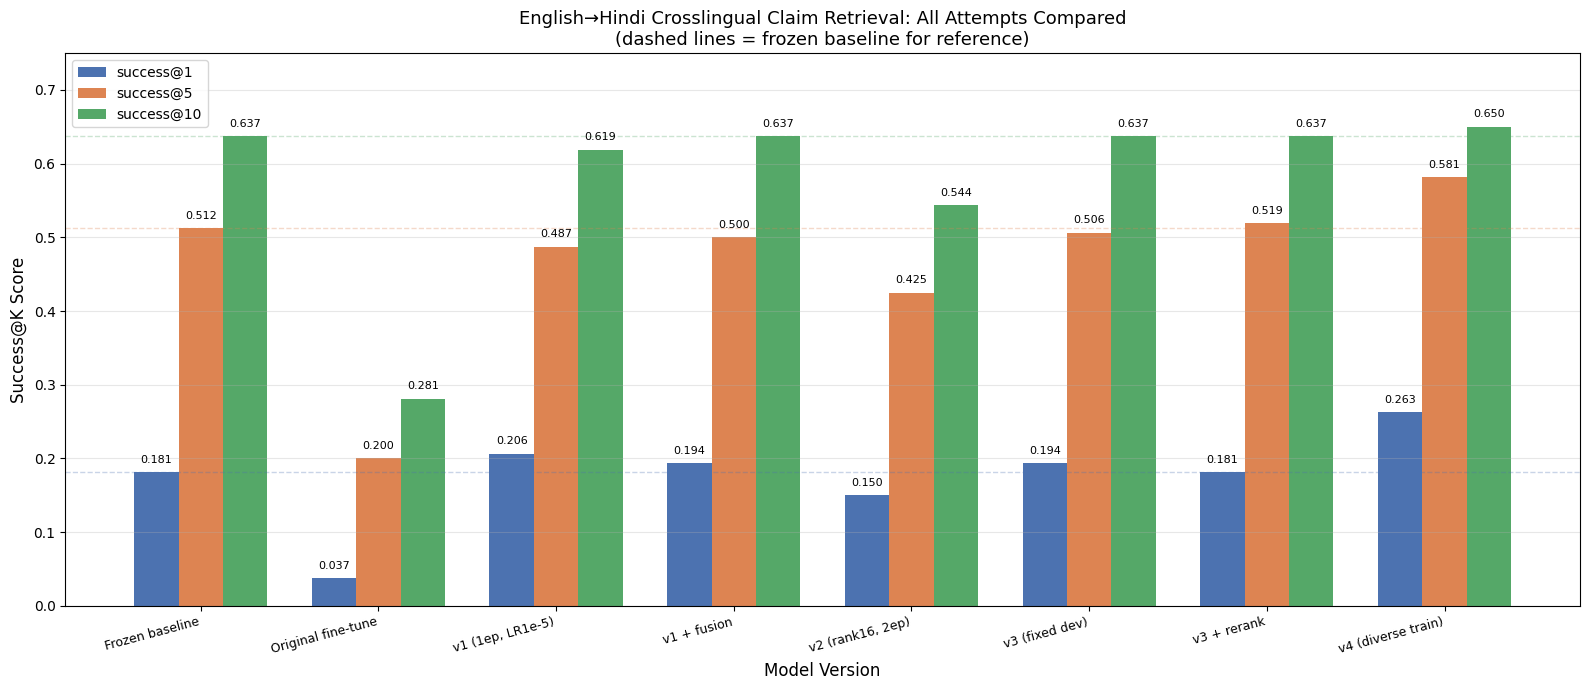

✅ Bar chart saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_comparison.png


In [4]:
labels = list(all_results.keys())
metrics = ['success@1', 'success@5', 'success@10']
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
for i, metric in enumerate(metrics):
    values = [all_results[l][metric] for l in labels]
    bars = ax.bar(x + i*width - width, values, width, label=metric, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

for i, metric in enumerate(metrics):
    ax.axhline(y=all_results['Frozen baseline'][metric], color=colors[i],
               linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Model Version', fontsize=12)
ax.set_ylabel('Success@K Score', fontsize=12)
ax.set_title('English→Hindi Crosslingual Claim Retrieval: All Attempts Compared\n'
             '(dashed lines = frozen baseline for reference)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 0.75)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

bar_path = os.path.join(REPORT_DIR, 'all_versions_comparison.png')
plt.savefig(bar_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Bar chart saved to: {bar_path}')

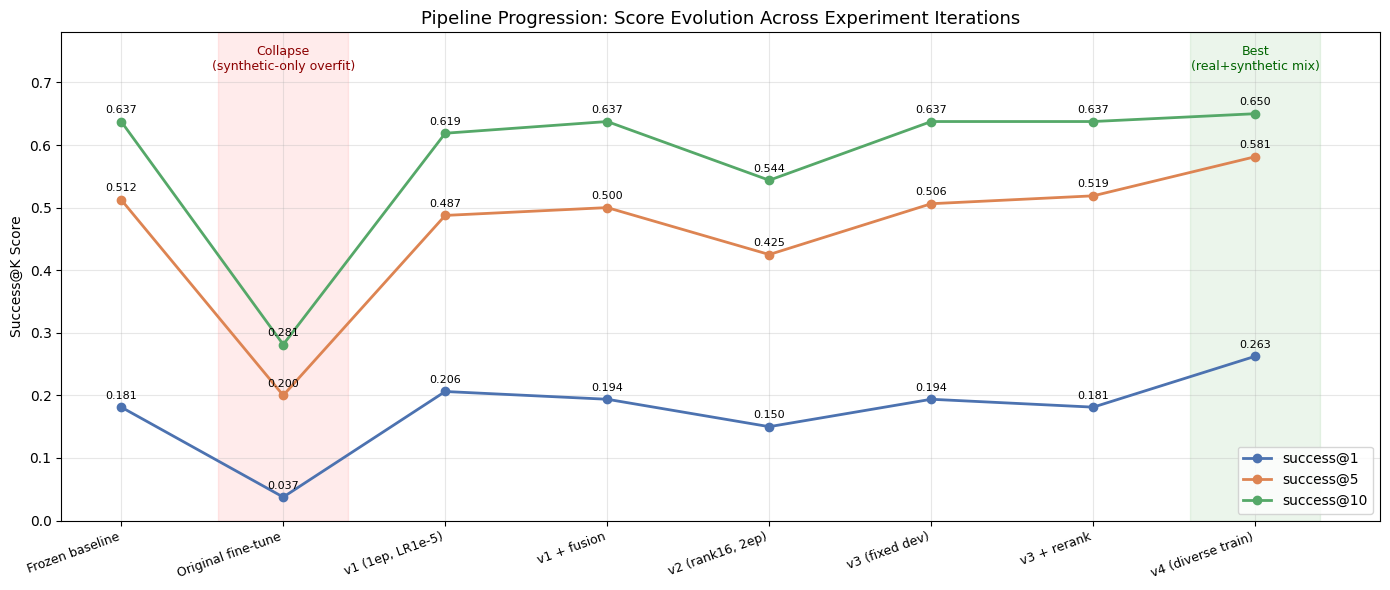

✅ Pipeline progression chart saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/pipeline_progression.png


In [6]:
# Chronological order the experiments actually happened in
pipeline_order = [
    'Frozen baseline', 'Original fine-tune', 'v1 (1ep, LR1e-5)',
    'v1 + fusion', 'v2 (rank16, 2ep)', 'v3 (fixed dev)',
    'v3 + rerank', 'v4 (diverse train)'
]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(pipeline_order))

for metric, color in zip(metrics, colors):
    y = [all_results[v][metric] for v in pipeline_order]
    ax.plot(x, y, marker='o', label=metric, color=color, linewidth=2)
    for xi, yi in zip(x, y):
        ax.annotate(f'{yi:.3f}', (xi, yi), textcoords="offset points",
                    xytext=(0, 6), ha='center', fontsize=8)

# Annotate the collapse and the eventual best
collapse_idx = pipeline_order.index('Original fine-tune')
best_idx = pipeline_order.index('v4 (diverse train)')
ax.axvspan(collapse_idx - 0.4, collapse_idx + 0.4, color='red', alpha=0.08)
ax.axvspan(best_idx - 0.4, best_idx + 0.4, color='green', alpha=0.08)
ax.text(collapse_idx, 0.72, 'Collapse\n(synthetic-only overfit)', ha='center', fontsize=9, color='darkred')
ax.text(best_idx, 0.72, 'Best\n(real+synthetic mix)', ha='center', fontsize=9, color='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(pipeline_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Success@K Score')
ax.set_ylim(0, 0.78)
ax.set_title('Pipeline Progression: Score Evolution Across Experiment Iterations', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

progression_path = os.path.join(REPORT_DIR, 'pipeline_progression.png')
plt.savefig(progression_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Pipeline progression chart saved to: {progression_path}')

In [7]:
best_version = max(all_results, key=lambda v: all_results[v]['success@10'])
baseline = all_results['Frozen baseline']
best = all_results[best_version]

print(f"Best version: {best_version}")
for m in metrics:
    delta = best[m] - baseline[m]
    print(f"  {m}: {best[m]:.4f}  (Δ vs frozen baseline: {delta:+.4f})")

print(f"\nAll outputs saved under: {REPORT_DIR}")

Best version: v4 (diverse train)
  success@1: 0.2625  (Δ vs frozen baseline: +0.0813)
  success@5: 0.5813  (Δ vs frozen baseline: +0.0688)
  success@10: 0.6500  (Δ vs frozen baseline: +0.0125)

All outputs saved under: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals


In [8]:
import os, json

OUTPUT_DIR = '/content/drive/MyDrive/semeval_eng_hin_crosslingual_results'
REPORT_DIR = os.path.join(OUTPUT_DIR, 'final_report_visuals')
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Raw results backup: source of truth, hand-typed once from actual runs ---
all_results = {
    'Frozen baseline':      {'success@1': 0.1812, 'success@5': 0.5125, 'success@10': 0.6375},
    'Original fine-tune':   {'success@1': 0.0375, 'success@5': 0.2000, 'success@10': 0.2812},
    'v1 (1ep, LR1e-5)':     {'success@1': 0.2062, 'success@5': 0.4875, 'success@10': 0.6188},
    'v1 + fusion':          {'success@1': 0.1938, 'success@5': 0.5000, 'success@10': 0.6375},
    'v2 (rank16, 2ep)':     {'success@1': 0.1500, 'success@5': 0.4250, 'success@10': 0.5437},
    'v3 (fixed dev)':       {'success@1': 0.1938, 'success@5': 0.5062, 'success@10': 0.6375},
    'v3 + rerank':          {'success@1': 0.1812, 'success@5': 0.5188, 'success@10': 0.6375},
    'v4 (diverse train)':   {'success@1': 0.2625, 'success@5': 0.5813, 'success@10': 0.6500},
}

raw_backup_path = os.path.join(REPORT_DIR, 'all_versions_results_RAW_BACKUP.json')
with open(raw_backup_path, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)

print(f'✅ Raw results dict backed up to: {raw_backup_path}')
print('   (re-load this file anytime to regenerate CSV/MD/tables/charts without re-deriving numbers)')

✅ Raw results dict backed up to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/all_versions_results_RAW_BACKUP.json
   (re-load this file anytime to regenerate CSV/MD/tables/charts without re-deriving numbers)


Improvement over Frozen Baseline (absolute Δ and % change):

                    success@1_abs  success@1_pct  success@5_abs  success@5_pct  success@10_abs  success@10_pct
version                                                                                                       
Original fine-tune        -0.1437       -79.3046        -0.3125       -60.9756         -0.3563        -55.8902
v1 (1ep, LR1e-5)           0.0250        13.7969        -0.0250        -4.8780         -0.0187         -2.9333
v1 + fusion                0.0126         6.9536        -0.0125        -2.4390          0.0000          0.0000
v2 (rank16, 2ep)          -0.0312       -17.2185        -0.0875       -17.0732         -0.0938        -14.7137
v3 (fixed dev)             0.0126         6.9536        -0.0063        -1.2293          0.0000          0.0000
v3 + rerank                0.0000         0.0000         0.0063         1.2293          0.0000          0.0000
v4 (diverse train)         0.0813        44.8675   

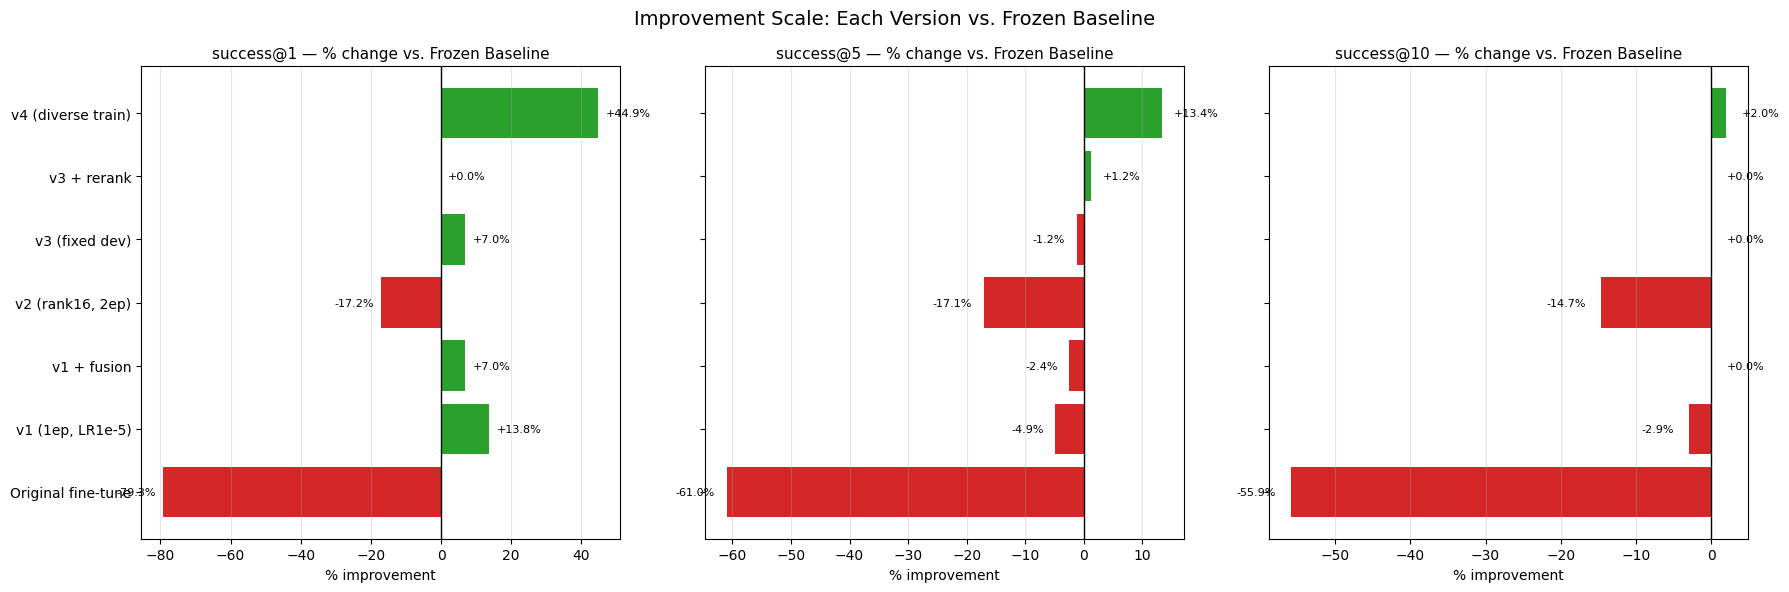

✅ Improvement scale chart saved to: /content/drive/MyDrive/semeval_eng_hin_crosslingual_results/final_report_visuals/improvement_scale.png

Headline: v4 (diverse train) improves success@1 by +44.9%, success@5 by +13.4%, success@10 by +2.0% over the frozen baseline.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

baseline = all_results['Frozen baseline']
metrics = ['success@1', 'success@5', 'success@10']
versions = [v for v in all_results if v != 'Frozen baseline']

# --- Compute absolute and relative (%) improvement over frozen baseline ---
improvement_rows = []
for v in versions:
    row = {'version': v}
    for m in metrics:
        abs_delta = all_results[v][m] - baseline[m]
        pct_delta = (abs_delta / baseline[m]) * 100
        row[f'{m}_abs'] = abs_delta
        row[f'{m}_pct'] = pct_delta
    improvement_rows.append(row)

df_improve = pd.DataFrame(improvement_rows).set_index('version')
print("Improvement over Frozen Baseline (absolute Δ and % change):\n")
print(df_improve.round(4).to_string())

# Save the improvement table too
improve_csv_path = os.path.join(REPORT_DIR, 'improvement_over_baseline.csv')
df_improve.to_csv(improve_csv_path)
print(f'\n✅ Improvement table saved to: {improve_csv_path}')

# --- Diverging bar chart: % improvement over baseline, per metric ---
colors_metric = ['#4C72B0', '#DD8452', '#55A868']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, metric, color in zip(axes, metrics, colors_metric):
    pct_vals = [df_improve.loc[v, f'{metric}_pct'] for v in versions]
    bar_colors = ['#2ca02c' if val >= 0 else '#d62728' for val in pct_vals]
    bars = ax.barh(versions, pct_vals, color=bar_colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{metric} — % change vs. Frozen Baseline', fontsize=11)
    ax.set_xlabel('% improvement')
    for bar, val in zip(bars, pct_vals):
        ax.text(val + (2 if val >= 0 else -2), bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Improvement Scale: Each Version vs. Frozen Baseline', fontsize=14)
plt.tight_layout()

improve_chart_path = os.path.join(REPORT_DIR, 'improvement_scale.png')
plt.savefig(improve_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Improvement scale chart saved to: {improve_chart_path}')

# --- Quick headline ---
best_v = 'v4 (diverse train)'
print(f"\nHeadline: {best_v} improves success@1 by "
      f"{df_improve.loc[best_v, 'success@1_pct']:+.1f}%, "
      f"success@5 by {df_improve.loc[best_v, 'success@5_pct']:+.1f}%, "
      f"success@10 by {df_improve.loc[best_v, 'success@10_pct']:+.1f}% over the frozen baseline.")